# Superstore End-to-End Data Analysis and ML Notebook

This notebook is rebuilt to be stable and beginner-friendly.

Simple -> Advanced learning path used in this notebook:
1. Import libraries and setup
2. Load dataset
3. Preview dataframe and shape
4. Check dtypes, missing values, and duplicates
5. Clean and format columns
6. EDA and statistical analysis
7. Feature engineering
8. Supervised and unsupervised machine learning
9. Business storytelling and conclusions


## 1. Imports and Setup

Why this block exists:
- Imports all required libraries once.
- Sets visualization style and warning behavior.
- Avoids repeated imports later.


In [39]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, silhouette_score
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### 1.1 Notebook Display and Style Setup

Why this block exists:
- Keeps tables readable for beginners.
- Sets one chart style for consistency.

In [40]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', palette='Set2')

print('Import and setup complete')

Import and setup complete


## 2. Load Dataset with Fallback Paths

Why this block exists:
- Your project can be opened from different folders.
- This code tries common file paths and stops when one works.


## Library Notes: Why These Are Used

Use this section as quick context for reviewers/interviewers.

- pandas: Data loading, cleaning, feature creation, and table operations.
- numpy: Fast numerical operations and array-level calculations.
- matplotlib: Reliable static plotting base.
- seaborn: Cleaner statistical charts for EDA.
- scikit-learn: Preprocessing, pipelines, model training, and evaluation.
- xgboost / lightgbm / catboost: Strong tabular boosting models for higher predictive accuracy.
- scipy / statsmodels: Statistical tests and interpretable statistical modeling.
- plotly: Interactive visuals for presentation and exploration.
- shap: Model explainability to show feature impact.
- optuna: Hyperparameter tuning to improve model performance.
- mlflow: Experiment tracking for reproducibility.

Template for future additions:
- Library: <name>
- Why used here: <project-specific reason>
- Where used: <cell/section/notebook>
- Limitation: <known tradeoff>

In [41]:
candidate_paths = [
    Path('SuperStoreOrders_SuperStoreOrders.csv'),
    Path('../SuperStoreOrders_SuperStoreOrders.csv'),
    Path('data/raw/SuperStoreOrders_SuperStoreOrders.csv')
]

# NOTE: This notebook uses the corrected CLEAN dataset with all valid records retained.
# Data engineering decisions:
#   - Keep all 51,290 valid business rows (no duplicate-row deletion required)
#   - Remove only spreadsheet artifacts (empty padding rows and Unnamed summary columns)
#   - Repair mixed date formats using robust parsing (default + dayfirst fallback)
#   - Standardize schema to clean lowercase_underscore columns

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('Dataset not found. Update candidate_paths.')

raw_df = pd.read_csv(data_path)

for dcol in ['order_date', 'ship_date']:
    if dcol in raw_df.columns:
        p1 = pd.to_datetime(raw_df[dcol], errors='coerce')
        p2 = pd.to_datetime(raw_df[dcol], errors='coerce', dayfirst=True)
        raw_df[dcol] = p1.fillna(p2)

print(f'Loaded: {data_path}')
print(f'Shape: {raw_df.shape}')
print('Duplicate rows:', int(raw_df.duplicated().sum()))
print(f'Date range: {raw_df["order_date"].min()} to {raw_df["order_date"].max()}')

Loaded: ..\SuperStoreOrders_SuperStoreOrders.csv
Shape: (51290, 22)
Duplicate rows: 0
Date range: 2011-01-01 00:00:00 to 2014-12-31 00:00:00


## 3. Standardize Column Names

Why this block exists:
- Many notebook errors happen because column names differ in capitalization and spacing.
- We convert all names to lowercase snake_case for consistency.


In [42]:
df = raw_df.copy()
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# Drop clearly empty unnamed columns if present
drop_unnamed = [c for c in df.columns if c.startswith('unnamed') or c == '']
if drop_unnamed:
    df = df.drop(columns=drop_unnamed)

# Keep only valid rows to avoid inflated missing-value counts from blank records.
if 'order_id' in df.columns:
    before_rows = len(df)
    df = df[df['order_id'].notna()].copy()
    removed_rows = before_rows - len(df)
    print(f'Removed rows with missing order_id: {removed_rows}')

print('Standardized columns:')
print(df.columns.tolist())

Removed rows with missing order_id: 0
Standardized columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'country', 'state', 'market', 'region', 'product_id', 'product_name', 'category', 'sub_category', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'sequence_number']


### 3.1 Preview Data: df.head()

Why this block exists:
- Shows the first 5 rows.
- Helps learners understand what the table looks like.

In [43]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Algeria,Constantine,Africa,Africa,OFF-TEN-10000025,"Tenex Lockers, Blue",Office Supplies,Storage,408,2.0,0.0,106.140,35.46,Medium,2011.0,1.0
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,OFF-SU-10000618,"Acme Trimmer, High Speed",Office Supplies,Supplies,120,3.0,0.1,36.036,9.72,Medium,2011.0,2.0
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Hungary,Budapest,EMEA,EMEA,OFF-TEN-10001585,"Tenex Box, Single Width",Office Supplies,Storage,66,4.0,0.0,29.640,8.17,High,2011.0,3.0
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Sweden,Stockholm,EU,North,OFF-PA-10001492,"Enermax Note Cards, Premium",Office Supplies,Paper,45,3.0,0.5,-26.055,4.82,High,2011.0,4.0
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings,114,5.0,0.1,37.770,4.70,Medium,2011.0,5.0


### 3.2 Check Data Size: df.shape

Why this block exists:
- Tells us how many rows and columns are in the dataset.

In [44]:
df.shape

(51290, 22)

### 3.3 Count Missing Values: df.isnull().sum()

Why this block exists:
- Missing values can cause errors in analysis and ML.
- We quickly check which columns have null values.

In [45]:
df.isnull().sum().sort_values(ascending=False).head(15)

order_id          0
order_date        0
year              0
order_priority    0
shipping_cost     0
profit            0
discount          0
quantity          0
sales             0
sub_category      0
category          0
product_name      0
product_id        0
region            0
market            0
dtype: int64

### 3.4 Data Summary: df.describe()

Why this block exists:
- Gives summary statistics such as count, mean, std, min, and max.
- Helps us understand numeric columns quickly.

In [46]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year,sequence_number
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.00000
mean,2013-04-30 17:16:21.384285440,2013-05-05 19:10:10.504971520,246.498440,3.476545,0.145278,28.641740,26.375915,2012.777208,25645.50000
min,2011-01-01 00:00:00,2011-01-02 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000,1.00000
25%,2012-06-06 00:00:00,2012-06-13 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000,12823.25000
50%,2013-06-26 00:00:00,2013-06-30 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000,25645.50000
75%,2014-04-30 00:00:00,2014-05-09 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000,38467.75000
max,2014-12-31 00:00:00,2015-07-01 00:00:00,22638.000000,14.000000,0.900000,8399.976000,933.570000,2014.000000,51290.00000
std,NaN,NaN,487.567175,2.278766,0.214113,174.424113,57.296804,1.098931,14806.29199


### 3.5 Extract Specific Columns from DataFrame

Why this block exists:
- Shows how to take only needed columns from a large dataset.
- This is a common beginner step before focused analysis.

In [47]:
basic_cols = [c for c in ['sales', 'profit', 'category', 'region'] if c in df.columns]
df[basic_cols].head()

,sales,profit,category,region
0,408,106.140,Office Supplies,Africa
1,120,36.036,Office Supplies,Oceania
2,66,29.640,Office Supplies,EMEA
3,45,-26.055,Office Supplies,North
4,114,37.770,Furniture,Oceania


## 4. Schema Mapping and Safety Checks

Why this block exists:
- Different Superstore files may use different labels.
- This map resolves actual column names for key business fields.


In [48]:
def pick_existing(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

schema = {
    'order_date': pick_existing(['order_date', 'orderdate'], df.columns),
    'ship_date': pick_existing(['ship_date', 'shipdate'], df.columns),
    'sales': pick_existing(['sales', 'revenue'], df.columns),
    'profit': pick_existing(['profit'], df.columns),
    'discount': pick_existing(['discount'], df.columns),
    'quantity': pick_existing(['quantity'], df.columns),
    'category': pick_existing(['category'], df.columns),
    'sub_category': pick_existing(['sub_category', 'subcategory'], df.columns),
    'segment': pick_existing(['segment'], df.columns),
    'region': pick_existing(['region'], df.columns),
    'state': pick_existing(['state'], df.columns),
    'customer_name': pick_existing(['customer_name', 'customer'], df.columns),
    'product_name': pick_existing(['product_name', 'product'], df.columns),
    'order_id': pick_existing(['order_id'], df.columns)
}

display(pd.DataFrame({'field': list(schema.keys()), 'resolved_column': list(schema.values())}))

required_for_eda = ['sales', 'profit']
missing_required = [k for k in required_for_eda if schema[k] is None]
if missing_required:
    raise ValueError(f'Missing required columns for EDA: {missing_required}')


,field,resolved_column
0,order_date,order_date
1,ship_date,ship_date
2,sales,sales
3,profit,profit
4,discount,discount
5,quantity,quantity
6,category,category
7,sub_category,sub_category
8,segment,segment
9,region,region


## 5. Data Types and Duplicate Rows

Why this block exists:
- After basic checks, we inspect column data types.
- We also check duplicate rows before cleaning.

In [49]:
print('Data types:')
display(df.dtypes.to_frame('dtype').T)

print('Duplicate rows:', df.duplicated().sum())

Data types:


,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number
dtype,object,datetime64[ns],datetime64[ns],object,object,object,object,object,object,object,object,object,object,object,int64,float64,float64,float64,float64,object,float64,float64


Duplicate rows: 0


## 6. Cleaning Step 1: Parse Dates and Numeric Fields

Why this block exists:
- Date columns need datetime type for trend analysis.
- Numeric columns must be numeric for stats and ML.


In [50]:
for dcol_key in ['order_date', 'ship_date']:
    dcol = schema[dcol_key]
    if dcol is not None:
        df[dcol] = pd.to_datetime(df[dcol], errors='coerce')

for ncol_key in ['sales', 'profit', 'discount', 'quantity']:
    ncol = schema[ncol_key]
    if ncol is not None:
        df[ncol] = pd.to_numeric(df[ncol], errors='coerce')

print('Type conversion complete.')


Type conversion complete.


## 7. Cleaning Step 2: Remove Duplicates and Handle Missing Values

Why this block exists:
- Exact duplicates can bias trends.
- We avoid dropping too much data; numeric nulls are imputed with median later in ML pipeline.
- For EDA, we clean critical fields only.


In [51]:
before_rows = len(df)
df = df.drop_duplicates().copy()
after_rows = len(df)

critical_cols = [schema['sales'], schema['profit']]
critical_cols = [c for c in critical_cols if c is not None]
df = df.dropna(subset=critical_cols).copy()

print('Rows before duplicate removal:', before_rows)
print('Rows after duplicate removal:', after_rows)
print('Rows after dropping nulls in critical cols:', len(df))


Rows before duplicate removal: 51290
Rows after duplicate removal: 51290
Rows after dropping nulls in critical cols: 51290


## 8. Feature Engineering

Why this block exists:
- Feature engineering creates informative input variables for analysis and ML.
- Examples: month, quarter, profit_margin, shipping_delay_days, loss_flag.


In [52]:
sales_col = schema['sales']
profit_col = schema['profit']
discount_col = schema['discount']
order_date_col = schema['order_date']
ship_date_col = schema['ship_date']

if order_date_col is not None:
    df['order_year'] = df[order_date_col].dt.year
    df['order_month'] = df[order_date_col].dt.month
    df['order_quarter'] = df[order_date_col].dt.quarter

df['profit_margin'] = np.where(df[sales_col] != 0, df[profit_col] / df[sales_col], np.nan)
df['loss_flag'] = (df[profit_col] < 0).astype(int)

if order_date_col is not None and ship_date_col is not None:
    df['shipping_delay_days'] = (df[ship_date_col] - df[order_date_col]).dt.days

if discount_col is not None:
    bins = [-0.01, 0, 0.1, 0.2, 0.4, 1.0]
    labels = ['No Discount', 'Low (0-10%)', 'Medium (10-20%)', 'High (20-40%)', 'Very High (40%+)']
    df['discount_bucket'] = pd.cut(df[discount_col], bins=bins, labels=labels)

display(df.head())


,order_id,order_date,ship_date,ship_mode,customer_name,segment,country,state,market,region,product_id,product_name,category,sub_category,sales,quantity,discount,profit,shipping_cost,order_priority,year,sequence_number,order_year,order_month,order_quarter,profit_margin,loss_flag,shipping_delay_days,discount_bucket
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Algeria,Constantine,Africa,Africa,OFF-TEN-10000025,"Tenex Lockers, Blue",Office Supplies,Storage,408,2.0,0.0,106.140,35.46,Medium,2011.0,1.0,2011,1,1,0.260147,0,151,No Discount
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,OFF-SU-10000618,"Acme Trimmer, High Speed",Office Supplies,Supplies,120,3.0,0.1,36.036,9.72,Medium,2011.0,2.0,2011,1,1,0.300300,0,212,Low (0-10%)
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Hungary,Budapest,EMEA,EMEA,OFF-TEN-10001585,"Tenex Box, Single Width",Office Supplies,Storage,66,4.0,0.0,29.640,8.17,High,2011.0,3.0,2011,1,1,0.449091,0,120,No Discount
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Sweden,Stockholm,EU,North,OFF-PA-10001492,"Enermax Note Cards, Premium",Office Supplies,Paper,45,3.0,0.5,-26.055,4.82,High,2011.0,4.0,2011,1,1,-0.579000,1,120,Very High (40%+)
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,Australia,New South Wales,APAC,Oceania,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings,114,5.0,0.1,37.770,4.70,Medium,2011.0,5.0,2011,1,1,0.331316,0,212,Low (0-10%)


## 9. Statistical Summary

Why this block exists:
- Gives descriptive statistics for numeric variables.
- Helps identify skewness and spread before modeling.


In [53]:
display(df.describe(include='number').T)


,count,mean,std,min,25%,50%,75%,max
sales,51290.0,246.498440,487.567175,0.000000,31.00,85.000000,251.000000,22638.0000
quantity,51290.0,3.476545,2.278766,1.000000,2.00,3.000000,5.000000,14.0000
discount,51290.0,0.145278,0.214113,0.000000,0.00,0.000000,0.200000,0.9000
profit,51290.0,28.641740,174.424113,-6599.978000,0.00,9.240000,36.810000,8399.9760
shipping_cost,51290.0,26.375915,57.296804,0.000000,2.61,7.790000,24.450000,933.5700
year,51290.0,2012.777208,1.098931,2011.000000,2012.00,2013.000000,2014.000000,2014.0000
sequence_number,51290.0,25645.500000,14806.291990,1.000000,12823.25,25645.500000,38467.750000,51290.0000
order_year,51290.0,2012.777208,1.098931,2011.000000,2012.00,2013.000000,2014.000000,2014.0000
order_month,51290.0,7.143420,3.394749,1.000000,4.00,7.000000,10.000000,12.0000
order_quarter,51290.0,2.683720,1.099181,1.000000,2.00,3.000000,4.000000,4.0000


## 10. EDA: Univariate Analysis

Why this block exists:
- Understand each numeric variable distribution independently.


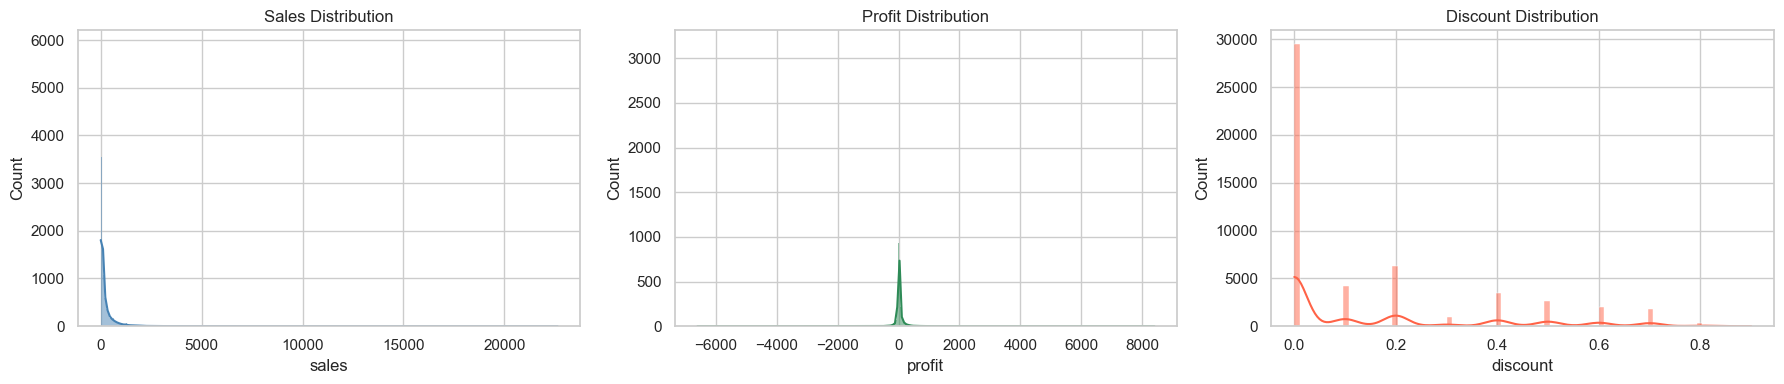

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df[sales_col], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Sales Distribution')

sns.histplot(df[profit_col], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Profit Distribution')

if discount_col is not None:
    sns.histplot(df[discount_col], kde=True, ax=axes[2], color='tomato')
    axes[2].set_title('Discount Distribution')
else:
    axes[2].text(0.3, 0.5, 'Discount column missing', fontsize=12)
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()


## 11. EDA: Categorical Performance

Why this block exists:
- Compare business groups by sales and profit (category, sub-category, segment, region).


In [55]:
for key in ['category', 'sub_category', 'segment', 'region', 'state']:
    col = schema[key]
    if col is not None:
        summary = df.groupby(col)[[sales_col, profit_col]].sum().sort_values(sales_col, ascending=False)
        print(f'\nPerformance by {col}:')
        display(summary.head(15))



Performance by category:


,sales,profit
category,,
Technology,4744691,663778.73318
Furniture,4110884,286782.25380
Office Supplies,3787330,518473.83430



Performance by sub_category:


,sales,profit
sub_category,,
Phones,1706874,216717.00580
Copiers,1509439,258567.54818
Chairs,1501682,141973.79750
Bookcases,1466559,161924.41950
Storage,1127124,108461.48980
Appliances,1011081,141680.58940
Machines,779071,58867.87300
Tables,757034,-64083.38870
Accessories,749307,129626.30620



Performance by segment:


,sales,profit
segment,,
Consumer,6508141,749239.78206
Corporate,3824808,442785.85866
Home Office,2309956,277009.18056



Performance by region:


,sales,profit
region,,
Central,2822399,311403.98164
South,1600960,140355.76618
North,1248192,194597.95252
Oceania,1100207,121666.64200
Southeast Asia,884438,17852.32900
North Asia,848349,165578.42100
EMEA,806184,43897.97100
Africa,783776,88871.63100
Central Asia,752839,132480.18700



Performance by state:


,sales,profit
state,,
England,485166,99907.73100
California,457731,76381.38710
Ile-de-France,317818,44055.92400
New York,310914,74038.54860
New South Wales,270509,45273.51400
Queensland,238311,21608.75400
North Rhine-Westphalia,216458,42347.87100
Texas,170187,-25729.35630
San Salvador,153648,35883.37700


### Step 12: Group and Aggregate

Why this block exists:
- Groups data and calculates summary values.
- It is kept as a separate step so beginners can learn one concept at a time.

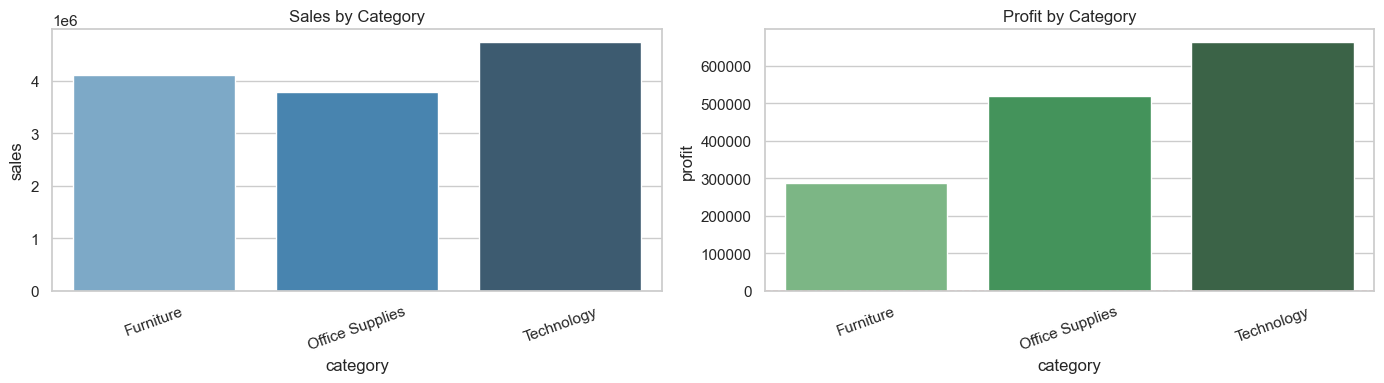

In [56]:
cat_col = schema['category']
if cat_col is not None:
    category_summary = df.groupby(cat_col)[[sales_col, profit_col]].sum().reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=category_summary, x=cat_col, y=sales_col, ax=axes[0], palette='Blues_d')
    axes[0].set_title('Sales by Category')
    axes[0].tick_params(axis='x', rotation=20)

    sns.barplot(data=category_summary, x=cat_col, y=profit_col, ax=axes[1], palette='Greens_d')
    axes[1].set_title('Profit by Category')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()


## 12. EDA: Discount Impact and Loss Analysis

Why this block exists:
- Checks whether higher discount levels are associated with lower profit.
- Identifies where losses are concentrated.


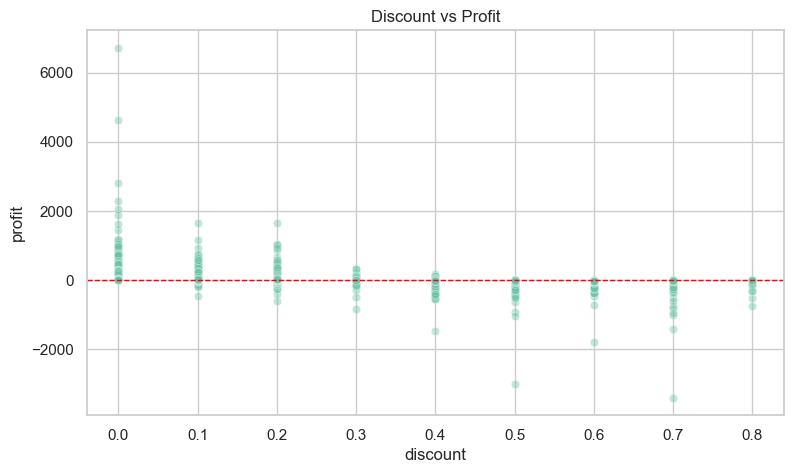

,discount_bucket,profit
0,No Discount,62.051980
1,Low (0-10%),66.806593
2,Medium (10-20%),27.341183
3,High (20-40%),-44.719241
4,Very High (40%+),-89.832373


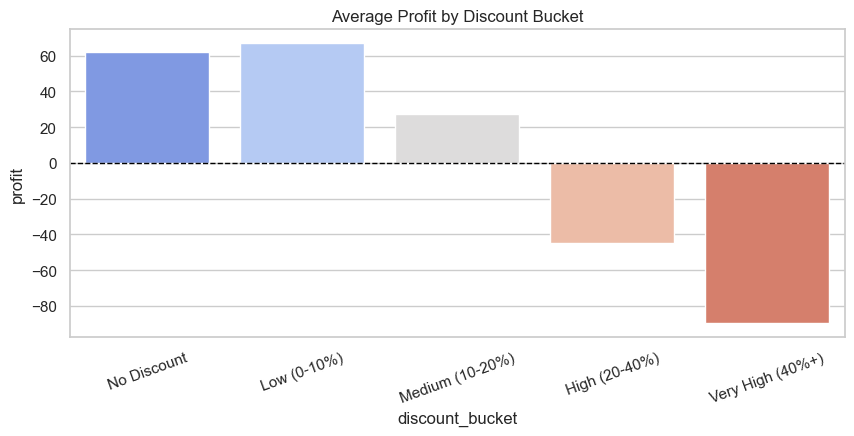

Loss-making orders: 12543
Loss share: 24.46%


In [57]:
if discount_col is not None:
    plot_df = df[[discount_col, profit_col]].dropna().copy()
    plot_df = plot_df.sample(min(5000, len(plot_df)), random_state=42)

    plt.figure(figsize=(9, 5))
    sns.scatterplot(data=plot_df, x=discount_col, y=profit_col, alpha=0.4)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.title('Discount vs Profit')
    plt.show()

if 'discount_bucket' in df.columns:
    bucket_profit = df.groupby('discount_bucket', observed=False)[profit_col].mean().reset_index()
    display(bucket_profit)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=bucket_profit, x='discount_bucket', y=profit_col, palette='coolwarm')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.xticks(rotation=20)
    plt.title('Average Profit by Discount Bucket')
    plt.show()

loss_df = df[df[profit_col] < 0].copy()
print('Loss-making orders:', len(loss_df))
print('Loss share: {:.2%}'.format(len(loss_df) / len(df)))


## 13. EDA: Time Series Trends

Why this block exists:
- Monthly trends reveal seasonality and growth or decline cycles.


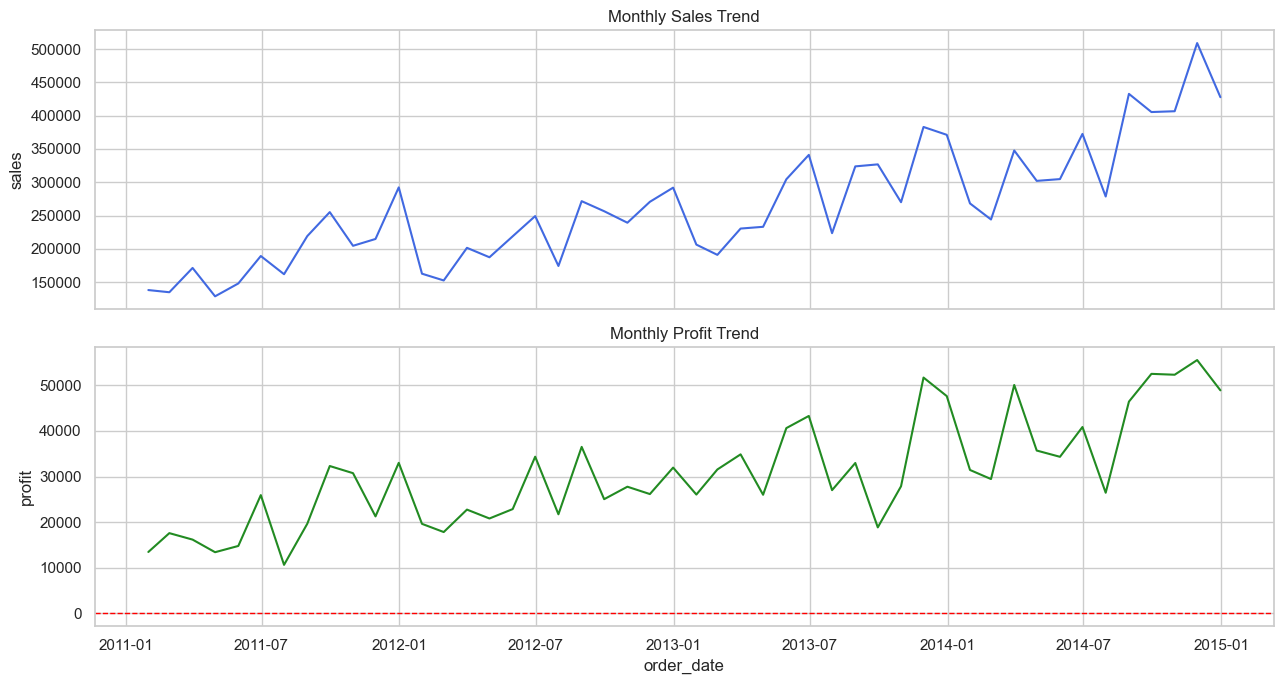

In [58]:
if order_date_col is not None:
    monthly = (
        df.set_index(order_date_col)
          .resample('M')[[sales_col, profit_col]]
          .sum()
          .reset_index()
    )

    fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    sns.lineplot(data=monthly, x=order_date_col, y=sales_col, ax=ax[0], color='royalblue')
    ax[0].set_title('Monthly Sales Trend')

    sns.lineplot(data=monthly, x=order_date_col, y=profit_col, ax=ax[1], color='forestgreen')
    ax[1].axhline(0, color='red', linestyle='--', linewidth=1)
    ax[1].set_title('Monthly Profit Trend')

    plt.tight_layout()
    plt.show()
else:
    print('order_date column not available for time trend analysis.')


## 14. Statistical Analysis

Why this block exists:
- Goes beyond charts and quantifies relationships.
- Pearson correlation: linear relationship between discount and profit.
- ANOVA: tests whether mean profit differs across categories.


Pearson correlation (discount vs profit): r=-0.3157, p-value=0.0000e+00
ANOVA across category for profit: F=304.2301, p-value=4.4891e-132


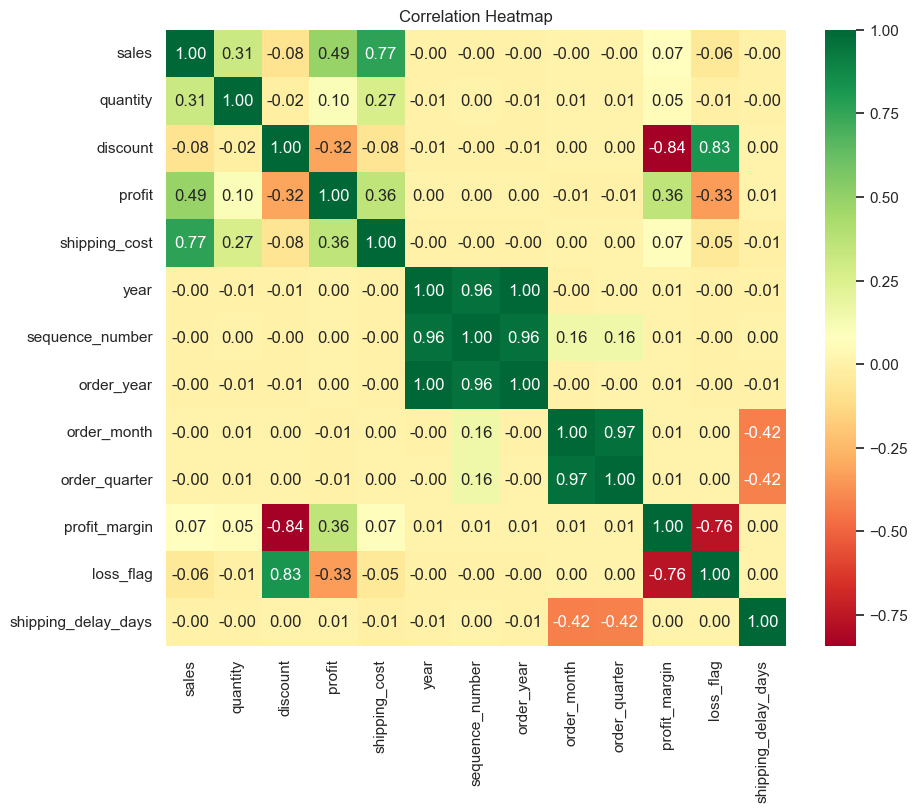

In [59]:
if discount_col is not None:
    corr_df = df[[discount_col, profit_col]].dropna()
    if len(corr_df) > 2:
        r, p = stats.pearsonr(corr_df[discount_col], corr_df[profit_col])
        print(f'Pearson correlation (discount vs profit): r={r:.4f}, p-value={p:.4e}')

cat_col = schema['category']
if cat_col is not None:
    groups = [g[profit_col].dropna().values for _, g in df.groupby(cat_col)]
    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        print(f'ANOVA across {cat_col} for profit: F={f_stat:.4f}, p-value={p_val:.4e}')

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, cmap='RdYlGn', annot=True, fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()


## 15. ML Concepts Quick Notes

Supervised Learning:
- Input X has features and output y is known during training.
- Regression predicts numbers (example: profit).
- Classification predicts classes (example: loss or no loss).

Unsupervised Learning:
- No target variable y during training.
- Clustering groups similar orders/customers (example: KMeans).

Feature Engineering:
- Creating better input variables from raw columns (month, margin, delay, buckets).


## 16. Supervised ML - Regression (Predict Profit)

Why this block exists:
- Builds and compares multiple regression algorithms.
- Uses a preprocessing pipeline to safely handle nulls and categories.
- Avoids target leakage by removing columns that are created from profit itself.

Important concept:
- Target leakage happens when the model is given information that directly contains the answer.
- Example: if we try to predict profit, then using `profit_margin` or `loss_flag` as inputs would be unfair because both are calculated from profit.

In [60]:
# 16a. Setup: Define target, exclude leakage columns, build feature matrix and preprocessor
target_reg = profit_col
exclude_cols = {target_reg, 'profit_margin', 'loss_flag'}

# Fast-mode switches for responsive iteration.
FAST_MODE = True
MAX_TRAIN_ROWS = 30000

for key in ['order_id', 'customer_name', 'product_name']:
    c = schema[key]
    if c is not None:
        exclude_cols.add(c)

# Also remove known high-cardinality ID-like fields if present.
for c in ['product_id', 'customer_id', 'row_id', 's_no', 'year', 'Unnamed:_29', 'Unnamed:_30', 'Unnamed:_31']:
    if c in df.columns:
        exclude_cols.add(c)

X_reg = df.drop(columns=list(exclude_cols), errors='ignore')
y_reg = df[target_reg].copy()

mask = y_reg.notna()
X_reg = X_reg.loc[mask].copy()
y_reg = y_reg.loc[mask].copy()

if FAST_MODE and len(X_reg) > MAX_TRAIN_ROWS:
    sampled_idx = X_reg.sample(n=MAX_TRAIN_ROWS, random_state=42).index
    X_reg = X_reg.loc[sampled_idx].copy()
    y_reg = y_reg.loc[sampled_idx].copy()

num_features = X_reg.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_reg.select_dtypes(exclude=[np.number]).columns.tolist()

high_card_cols = [c for c in cat_features if X_reg[c].nunique(dropna=True) > 300]
if high_card_cols:
    X_reg = X_reg.drop(columns=high_card_cols)
    cat_features = [c for c in cat_features if c not in high_card_cols]

for col in cat_features:
    X_reg[col] = X_reg[col].astype('string').fillna('missing').astype('category')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_features)
    ]
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_results = []
reg_pipes = {}

print(f'Train size: {X_train_r.shape[0]} rows | Test size: {X_test_r.shape[0]} rows')
print(f'Features — Numeric: {len(num_features)} | Categorical: {len(cat_features)}')
print('Dropped high-cardinality columns:', high_card_cols[:8], '...' if len(high_card_cols) > 8 else '')
print('FAST_MODE:', FAST_MODE)


Train size: 24000 rows | Test size: 6000 rows
Features — Numeric: 9 | Categorical: 9
Dropped high-cardinality columns: ['order_date', 'ship_date', 'state'] 
FAST_MODE: True


In [61]:
# 16b. Train Model 1: Linear Regression (fast — usually completes in seconds)
print('Training LinearRegression...')
pipe_lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
pipe_lr.fit(X_train_r, y_train_r)
pred_lr = pipe_lr.predict(X_test_r)

reg_results.append({
    'Model': 'LinearRegression',
    'MAE': mean_absolute_error(y_test_r, pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, pred_lr)),
    'R2': r2_score(y_test_r, pred_lr)
})
reg_pipes['LinearRegression'] = pipe_lr
print(f'Done. R2 = {r2_score(y_test_r, pred_lr):.4f}')


Training LinearRegression...
Done. R2 = 0.2621


In [62]:
# 16c. Train Model 2: Random Forest Regressor
rf_trees = 60 if ('FAST_MODE' in globals() and FAST_MODE) else 100
print(f'Training RandomForestRegressor (n_estimators={rf_trees})...')
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=rf_trees,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])
pipe_rf.fit(X_train_r, y_train_r)
pred_rf = pipe_rf.predict(X_test_r)

reg_results.append({
    'Model': 'RandomForestRegressor',
    'MAE': mean_absolute_error(y_test_r, pred_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, pred_rf)),
    'R2': r2_score(y_test_r, pred_rf)
})
reg_pipes['RandomForestRegressor'] = pipe_rf
print(f'Done. R2 = {r2_score(y_test_r, pred_rf):.4f}')


Training RandomForestRegressor (n_estimators=60)...
Done. R2 = 0.5533


In [66]:
# 16d. Train Model 3: Gradient Boosting Regressor
# n_estimators=50, max_depth=4 keeps it fast while still outperforming linear models.
# Raise to n_estimators=100 only if you want higher accuracy and can wait longer.
print('Training GradientBoostingRegressor...')
pipe_gbr = Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(n_estimators=50, max_depth=4, random_state=42))])
pipe_gbr.fit(X_train_r, y_train_r)
pred_gbr = pipe_gbr.predict(X_test_r)

reg_results.append({
    'Model': 'GradientBoostingRegressor',
    'MAE': mean_absolute_error(y_test_r, pred_gbr),
    'RMSE': np.sqrt(mean_squared_error(y_test_r, pred_gbr)),
    'R2': r2_score(y_test_r, pred_gbr)
})
reg_pipes['GradientBoostingRegressor'] = pipe_gbr
print(f'Done. R2 = {r2_score(y_test_r, pred_gbr):.4f}')


Training GradientBoostingRegressor...
Done. R2 = 0.6287


In [67]:
# 16e. Compare all regression model results
reg_results_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
display(reg_results_df)


,Model,MAE,RMSE,R2
2,GradientBoostingRegressor,36.649009,107.489450,0.628695
3,GradientBoostingRegressor,36.649009,107.489450,0.628695
1,RandomForestRegressor,35.546616,117.894468,0.553330
0,LinearRegression,57.550696,151.530598,0.262096


### Step 17: Create Visualization

Why this block exists:
- Builds charts to understand patterns in the data.
- It is kept as a separate step so beginners can learn one concept at a time.

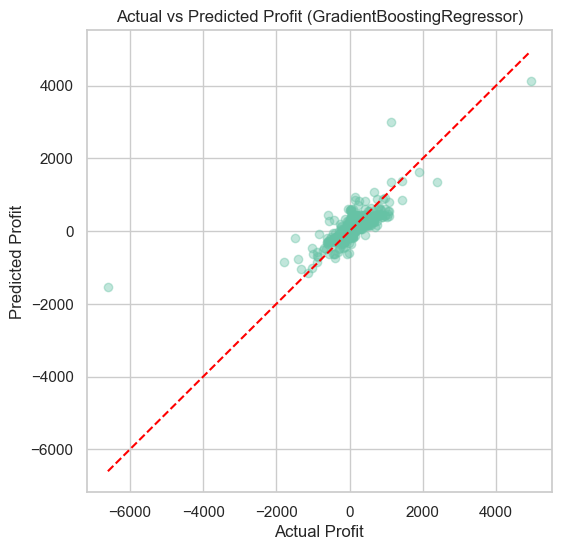

In [68]:
best_reg_name = reg_results_df.iloc[0]['Model']
best_reg_pipe = reg_pipes[best_reg_name]
best_pred_reg = best_reg_pipe.predict(X_test_r)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, best_pred_reg, alpha=0.4)
low = min(y_test_r.min(), best_pred_reg.min())
high = max(y_test_r.max(), best_pred_reg.max())
plt.plot([low, high], [low, high], 'r--')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title(f'Actual vs Predicted Profit ({best_reg_name})')
plt.show()


## 17. Supervised ML - Classification (Predict Loss Risk)

Why this block exists:
- Creates binary target: 1 means loss-making order, 0 means profitable or break-even order.
- Helps create a risk-warning system for future orders.
- Reuses the same cleaned feature matrix from the regression section so we do not accidentally leak the target.

Important concept:
- Classification predicts categories, not numbers.
- Here the input is order information and the output is a class label: loss or not loss.

In [69]:
# 17a. Setup: Classification target, feature matrix, and train/test split
y_clf = df['loss_flag'].copy()
X_clf = X_reg.copy()

# Align y to the sampled X index (FAST_MODE samples X_reg to 30k rows)
y_clf = y_clf.loc[X_clf.index]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf_results = []
clf_pipes = {}

print(f'Train size: {X_train_c.shape[0]} rows | Test size: {X_test_c.shape[0]} rows')
print(f'Loss rate in train: {y_train_c.mean():.2%} | in test: {y_test_c.mean():.2%}')


Train size: 24000 rows | Test size: 6000 rows
Loss rate in train: 24.46% | in test: 24.45%


In [70]:
# 17b. Train Model 1: Logistic Regression (fast — usually completes in seconds)
print('Training LogisticRegression...')
pipe_logreg = Pipeline([('prep', preprocessor), ('model', LogisticRegression(max_iter=3000))])
pipe_logreg.fit(X_train_c, y_train_c)
pred_logreg = pipe_logreg.predict(X_test_c)
proba_logreg = pipe_logreg.predict_proba(X_test_c)[:, 1]

clf_results.append({
    'Model': 'LogisticRegression',
    'Accuracy': accuracy_score(y_test_c, pred_logreg),
    'Precision': precision_score(y_test_c, pred_logreg, zero_division=0),
    'Recall': recall_score(y_test_c, pred_logreg, zero_division=0),
    'F1': f1_score(y_test_c, pred_logreg, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test_c, proba_logreg)
})
clf_pipes['LogisticRegression'] = pipe_logreg
print(f'Done. F1 = {f1_score(y_test_c, pred_logreg, zero_division=0):.4f}')


Training LogisticRegression...
Done. F1 = 0.8581


In [71]:
# 17c. Train Model 2: Random Forest Classifier (n_estimators=100 for speed)
print('Training RandomForestClassifier (n_estimators=100)...')
pipe_rfc = Pipeline([('prep', preprocessor), ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
pipe_rfc.fit(X_train_c, y_train_c)
pred_rfc = pipe_rfc.predict(X_test_c)
proba_rfc = pipe_rfc.predict_proba(X_test_c)[:, 1]

clf_results.append({
    'Model': 'RandomForestClassifier',
    'Accuracy': accuracy_score(y_test_c, pred_rfc),
    'Precision': precision_score(y_test_c, pred_rfc, zero_division=0),
    'Recall': recall_score(y_test_c, pred_rfc, zero_division=0),
    'F1': f1_score(y_test_c, pred_rfc, zero_division=0),
    'ROC_AUC': roc_auc_score(y_test_c, proba_rfc)
})
clf_pipes['RandomForestClassifier'] = pipe_rfc
print(f'Done. F1 = {f1_score(y_test_c, pred_rfc, zero_division=0):.4f}')


Training RandomForestClassifier (n_estimators=100)...
Done. F1 = 0.8579


In [72]:
# 17d. Compare all classification model results
clf_results_df = pd.DataFrame(clf_results).sort_values('F1', ascending=False)
display(clf_results_df)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,0.933333,0.894893,0.824131,0.858055,0.979693
1,RandomForestClassifier,0.933333,0.896065,0.822768,0.857854,0.979233


### Step 19: Create Visualization

Why this block exists:
- Builds charts to understand patterns in the data.
- It is kept as a separate step so beginners can learn one concept at a time.

Best classifier: LogisticRegression
              precision    recall  f1-score   support

           0      0.945     0.969     0.956      4533
           1      0.895     0.824     0.858      1467

    accuracy                          0.933      6000
   macro avg      0.920     0.896     0.907      6000
weighted avg      0.932     0.933     0.932      6000



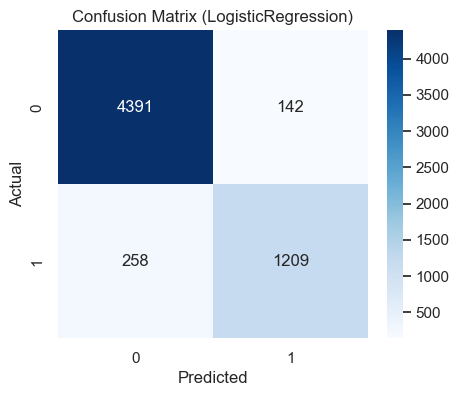

In [73]:
best_clf_name = clf_results_df.iloc[0]['Model']
best_clf_pipe = clf_pipes[best_clf_name]
best_pred_clf = best_clf_pipe.predict(X_test_c)

print(f'Best classifier: {best_clf_name}')
print(classification_report(y_test_c, best_pred_clf, digits=3))

cm = confusion_matrix(y_test_c, best_pred_clf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix ({best_clf_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 18. Unsupervised ML - Clustering (Customer or Order Patterns)

Why this block exists:
- Demonstrates unsupervised learning where no target `y` is used.
- KMeans groups similar rows based on selected numeric features.
- Uses sampled silhouette scoring so the notebook stays memory-safe on large datasets.

Important concept:
- Unsupervised learning does not know the correct answers in advance.
- It only looks for hidden patterns or natural groups in the data.

,k,silhouette
0,2,0.589104
1,3,0.349065
2,4,0.339962
3,5,0.358519


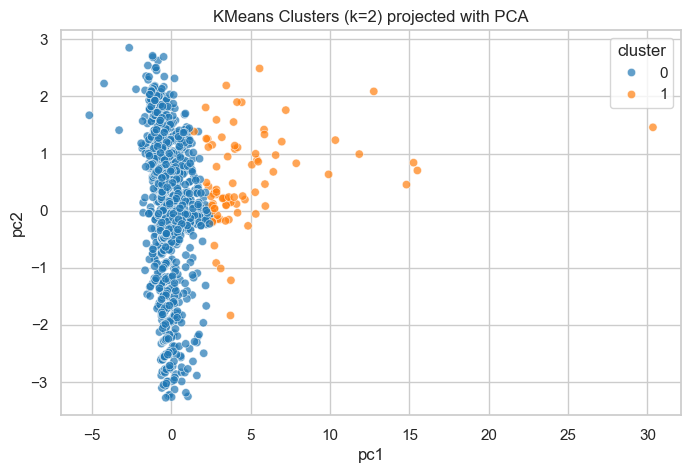

Cluster profile means (sample used for clustering):


,sales,profit,discount,quantity,shipping_delay_days
cluster,,,,,
0,175.241649,15.954714,0.149113,3.377349,5.173278
1,2181.476190,526.492000,0.069048,6.083333,23.559524


In [74]:
cluster_features = [
    c for c in [sales_col, profit_col, discount_col, schema['quantity'], 'shipping_delay_days']
    if c is not None and c in df.columns
]
cluster_df = df[cluster_features].dropna().copy()

if len(cluster_features) >= 2 and len(cluster_df) >= 50:
    scaler = StandardScaler()
    X_cluster = scaler.fit_transform(cluster_df)

    # Limit sample to 2000 rows — enough for reliable silhouette scoring, much faster.
    sample_size = min(2000, len(cluster_df))
    sample_idx = np.random.RandomState(42).choice(len(cluster_df), size=sample_size, replace=False)
    X_cluster_sample = X_cluster[sample_idx]

    # Test k=2 to 5 (skip 6 to save time; diminishing returns beyond k=5 for this dataset).
    sil_scores = []
    for k in range(2, 6):
        km = KMeans(n_clusters=k, random_state=42, n_init=5)
        labels_sample = km.fit_predict(X_cluster_sample)
        sil_scores.append((
            k,
            silhouette_score(X_cluster_sample, labels_sample, sample_size=min(1000, len(X_cluster_sample)), random_state=42)
        ))

    sil_df = pd.DataFrame(sil_scores, columns=['k', 'silhouette'])
    display(sil_df)

    best_k = int(sil_df.sort_values('silhouette', ascending=False).iloc[0]['k'])
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=5)
    final_labels = km_final.fit_predict(X_cluster_sample)

    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_cluster_sample)

    plot_clusters = pd.DataFrame({
        'pc1': coords[:, 0],
        'pc2': coords[:, 1],
        'cluster': final_labels
    })
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=plot_clusters, x='pc1', y='pc2', hue='cluster', palette='tab10', alpha=0.7)
    plt.title(f'KMeans Clusters (k={best_k}) projected with PCA')
    plt.show()

    cluster_profile = cluster_df.iloc[sample_idx].copy()
    cluster_profile['cluster'] = final_labels
    print('Cluster profile means (sample used for clustering):')
    display(cluster_profile.groupby('cluster').mean(numeric_only=True))
else:
    print('Not enough clean numeric data for clustering section.')


## 19. Cross-Validation Reliability Check

Why this block exists:
- One train/test split can be lucky or unlucky.
- Cross-validation gives more reliable performance estimate.


In [75]:
# Cross-validation reliability check with fast-mode guardrails.
cv_rows = min(10000, len(X_reg)) if ('FAST_MODE' in globals() and FAST_MODE) else len(X_reg)
if cv_rows < len(X_reg):
    cv_idx = X_reg.sample(n=cv_rows, random_state=42).index
    X_cv = X_reg.loc[cv_idx]
    y_cv = y_reg.loc[cv_idx]
else:
    X_cv, y_cv = X_reg, y_reg

cv_folds = 3 if ('FAST_MODE' in globals() and FAST_MODE) else 5
rf_trees_cv = 60 if ('FAST_MODE' in globals() and FAST_MODE) else 120

cv = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
cv_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=rf_trees_cv,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

cv_scores = cross_val_score(cv_pipe, X_cv, y_cv, cv=cv, scoring='r2', n_jobs=-1)
print('CV rows used:', len(X_cv))
print('CV folds:', cv_folds)
print('CV R2 scores:', np.round(cv_scores, 4))
print('Mean CV R2:', np.round(cv_scores.mean(), 4))
print('Std CV R2:', np.round(cv_scores.std(), 4))


CV rows used: 10000
CV folds: 3
CV R2 scores: [0.6748 0.3516 0.3981]
Mean CV R2: 0.4749
Std CV R2: 0.1427


## 20. Business Storytelling Template

Use this format in your final report:
1. What happened: sales/profit trend summary
2. Why it happened: discount and category effects
3. What may happen next: ML predictions
4. What to do now: action recommendations


In [76]:
lines = []

if schema['category'] is not None:
    top_sales_cat = df.groupby(schema['category'])[sales_col].sum().sort_values(ascending=False).index[0]
    top_profit_cat = df.groupby(schema['category'])[profit_col].sum().sort_values(ascending=False).index[0]
    lines.append(f'Top sales category: {top_sales_cat}; top profit category: {top_profit_cat}.')

if schema['sub_category'] is not None:
    worst_sub = df.groupby(schema['sub_category'])[profit_col].sum().sort_values().index[0]
    lines.append(f'Most loss-making sub-category: {worst_sub}.')

if 'discount_bucket' in df.columns:
    worst_bucket = df.groupby('discount_bucket', observed=False)[profit_col].mean().sort_values().index[0]
    lines.append(f'Weakest discount bucket by average profit: {worst_bucket}.')

if 'reg_results_df' in globals() and not reg_results_df.empty:
    best = reg_results_df.iloc[0]
    lines.append(f'Best regression model: {best.Model} with R2={best.R2:.3f}.')

if 'clf_results_df' in globals() and not clf_results_df.empty:
    bestc = clf_results_df.iloc[0]
    lines.append(f'Best classifier: {bestc.Model} with F1={bestc.F1:.3f}.')

lines.append('Recommendation: apply discount guardrails, focus high-margin segments, and use model-based risk checks before discount-heavy deals.')

print('Executive Summary Draft')
for i, ln in enumerate(lines, 1):
    print(f'{i}. {ln}')


Executive Summary Draft
1. Top sales category: Technology; top profit category: Technology.
2. Most loss-making sub-category: Tables.
3. Weakest discount bucket by average profit: Very High (40%+).
4. Best regression model: GradientBoostingRegressor with R2=0.629.
5. Best classifier: LogisticRegression with F1=0.858.
6. Recommendation: apply discount guardrails, focus high-margin segments, and use model-based risk checks before discount-heavy deals.


## 21. Final Conclusion

You now have a complete workflow:
- Import and robust loading
- Data cleaning and quality checks
- EDA and statistical validation
- Supervised ML: regression and classification
- Unsupervised ML: clustering
- Storytelling for decision-making

Suggested next upgrades:
1. Hyperparameter tuning with Optuna
2. Model explainability with SHAP
3. Dashboard with Plotly/Streamlit
